# Modelo Prophet
En este notebook implementamos el modelo **Prophet** de Facebook. A diferencia del modelo ARIMA anterior, Prophet está diseñado para manejar automáticamente la estacionalidad (diaria, semanal y anual) y los efectos de los festivos, lo que debería permitir capturar mejor los ciclos de ventas de la empresa.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Se cargan los datos de entrenamiento y test
train_df = pd.read_csv('../../data/processed/train_val.csv', parse_dates=['Date'])
test_df = pd.read_csv('../../data/processed/test.csv', parse_dates=['Date'])

# Preparamos el formato específico para Prophet
train_prophet = train_df[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
test_prophet = test_df[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

print(f"[INFO] Dataset de entrenamiento listo: {train_prophet.shape}")

[INFO] Dataset de entrenamiento listo: (277, 2)


In [3]:
# Inicializamos el modelo con estacionalidades activadas
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False
)

# Entrenamos el modelo
model.fit(train_prophet)

00:04:19 - cmdstanpy - INFO - Chain [1] start processing
00:04:21 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
# Creamos el dataframe para la predicción (periodo de test: 31 días)
future = test_prophet[['ds']]
forecast = model.predict(future)

# Unimos predicción con valores reales para evaluación
test_prophet['Predictions_Prophet'] = forecast['yhat'].values

In [5]:
# Calculamos el error
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], test_prophet['Predictions_Prophet']))

print(f"--------------------------------------------------")
print(f"[RESULT] RMSE FINAL (PROPHET): {rmse_prophet:.2f}")
print(f"--------------------------------------------------")

--------------------------------------------------
[RESULT] RMSE FINAL (PROPHET): 11362.20
--------------------------------------------------


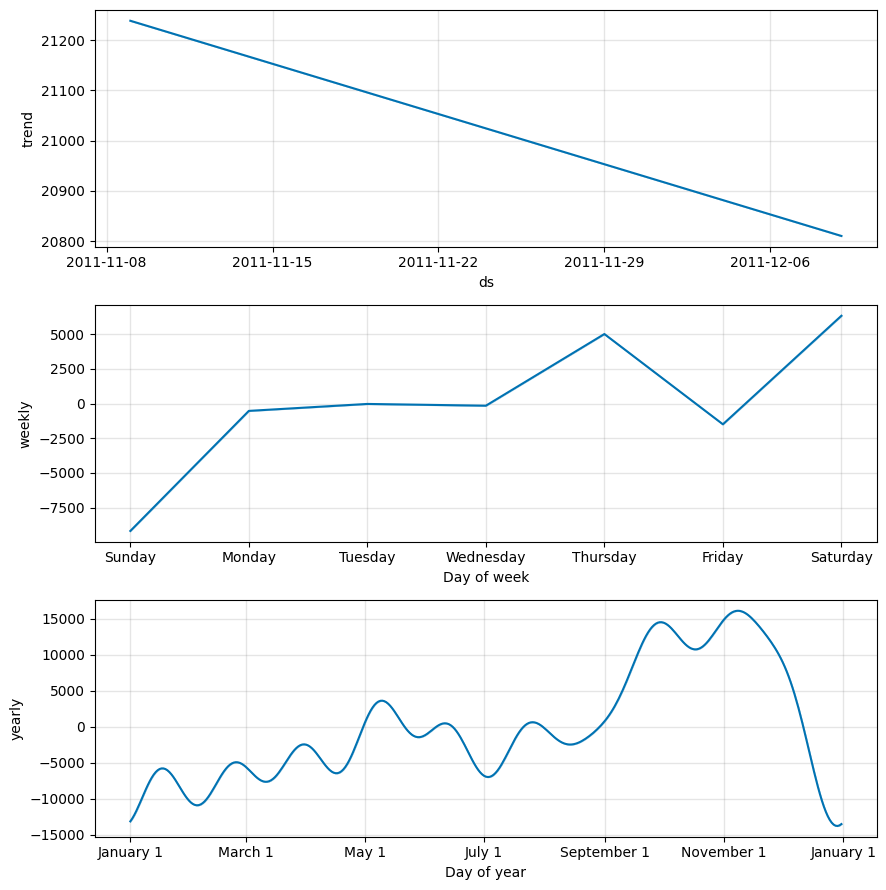

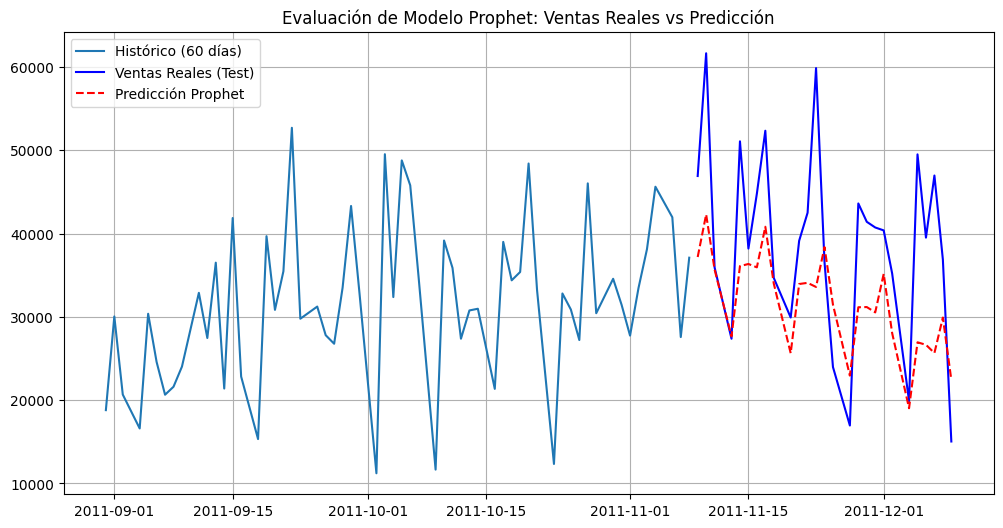

In [6]:
#  visualizamos los componentes
fig_comp = model.plot_components(forecast)
plt.show()

# Generamos una visualización de comparativa entre ventas reales y ventas predictivas
plt.figure(figsize=(12, 6))
plt.plot(train_prophet['ds'].iloc[-60:], train_prophet['y'].iloc[-60:], label='Histórico (60 días)')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Ventas Reales (Test)', color='blue')
plt.plot(test_prophet['ds'], test_prophet['Predictions_Prophet'], label='Predicción Prophet', color='red', linestyle='--')

plt.title('Evaluación de Modelo Prophet: Ventas Reales vs Predicción')
plt.legend()
plt.grid(True)
plt.show()